实验一  图1：各个状态随时间变化图

In [6]:
import matplotlib.font_manager as fm

# 列出所有支持中文的字体
fonts = [f.name for f in fm.fontManager.ttflist if 'CJK' in f.name or 'Hei' in f.name or 'Song' in f.name]
print(sorted(set(fonts)))


from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
# 忽略FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

# 读取数据
data_MMCA = pd.read_csv('./MMCA_results_mean.csv')
data_MC   = pd.read_csv('./MC_mean_results.csv')

data_MC = data_MC.iloc[::2]  # 每隔 5 个点取一个
data_MMCA = data_MMCA.iloc[::1]

print(data_MMCA.head())
print(data_MC.head())

['FangSong', 'Microsoft JhengHei', 'Microsoft YaHei', 'STSong', 'SimHei']
         US        AS        AI        UR        AR
0  0.990000  0.000000  0.010000  0.000000  0.000000
1  0.982026  0.001973  0.015002  0.000150  0.000850
2  0.969929  0.005149  0.022422  0.000502  0.001998
3  0.951902  0.010032  0.033324  0.001135  0.003607
4  0.925554  0.017261  0.049111  0.002165  0.005909
         US        AS        AI        UR        AR
0  0.990000  0.000000  0.010000  0.000000  0.000000
2  0.969910  0.005150  0.022439  0.000502  0.001999
4  0.925466  0.017272  0.049182  0.002167  0.005914
6  0.835721  0.041633  0.102485  0.006139  0.014021
8  0.680671  0.080820  0.193783  0.014437  0.030290


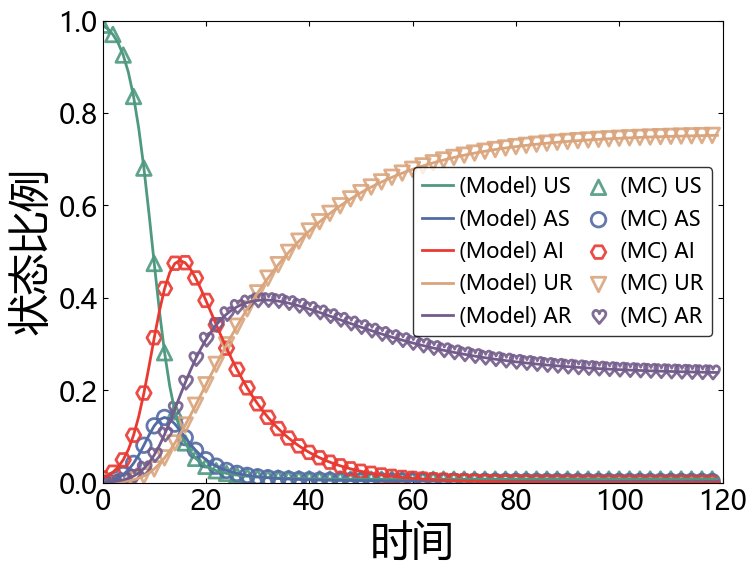

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 或其他字体名称
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))

states_labels = ['US', 'AS', 'AI', 'UR', 'AR']
# colors = ['#415a77', '#249087', '#E54C5E', '#a7c957', '#f77f00']
colors = ['#4E9980', '#526BA4', '#E93A32', '#DAA57C', '#735C8B']
markers = ['^', 'o', 'H', 'v', '$\u2665$']

for i, (label, color) in enumerate(zip(states_labels, colors)):
    sns.lineplot(data = data_MMCA[label], linewidth=2, color=color, label=f'(Model) {label}')

for i, (label, color, marker) in enumerate(zip(states_labels, colors, markers)):
    sns.scatterplot(data = data_MC[label], linewidth=2, s=110, color=color,edgecolor=color, facecolor='none',
                     label=f'(MC) {label}', marker=marker, alpha=0.9)

plt.xlabel('时间',fontsize='30')
plt.ylabel('状态比例',fontsize='30')
plt.xticks(fontsize='20')
plt.xlim(0, 120)  # 设置x轴范围
plt.yticks(fontsize='20')
plt.ylim(0, 1)  # 设置y轴范围

# plt.legend(
#     fontsize=20, bbox_to_anchor=(1.25, 0.5),  # 图例的锚点位置（1.05表示右侧外部，1表示顶部对齐）
#     loc="center left",           # 图例的锚点对齐方式
#     borderaxespad=-4          # 图例与轴的间距
# )
# 设置 legend 对齐和边框

legend = plt.legend(
    loc='center right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    ncol=2,              # 分两列
    handlelength=1.5,    # 统一图标宽度
    columnspacing=0.5,     # 缩小列间距（默认2.0）
)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)



legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

# 保存为pdf
plt.savefig('test1_1.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [8]:
import pandas as pd

def transform_to_SIR(data):
    return pd.DataFrame({
        'S': data['US'] + data['AS'],  
        'I': data['AI'],               
        'R': data['AR'] + data['UR']   
    })

data_MMCA_SIR = transform_to_SIR(data_MMCA)
data_MC_SIR = transform_to_SIR(data_MC)

def transform_to_UAU(data):
    return pd.DataFrame({
        'U': data['US'] + data['UR'],  
        'A': data['AI'] + data['AR'] + data['AS']            
    })

data_MMCA_UAU = transform_to_UAU(data_MMCA)
data_MC_UAU = transform_to_UAU(data_MC)

print("data_MMCA (SIR format):")
print(data_MMCA_SIR.head())

print("\ndata_MC (UAU format):")
print(data_MMCA_UAU.head())

data_MMCA (SIR format):
          S         I         R
0  0.990000  0.010000  0.000000
1  0.983998  0.015002  0.001000
2  0.975078  0.022422  0.002500
3  0.961934  0.033324  0.004742
4  0.942815  0.049111  0.008075

data_MC (UAU format):
          U         A
0  0.990000  0.010000
1  0.982176  0.017824
2  0.970430  0.029570
3  0.953037  0.046963
4  0.927719  0.072281


图2： 分解为SIR

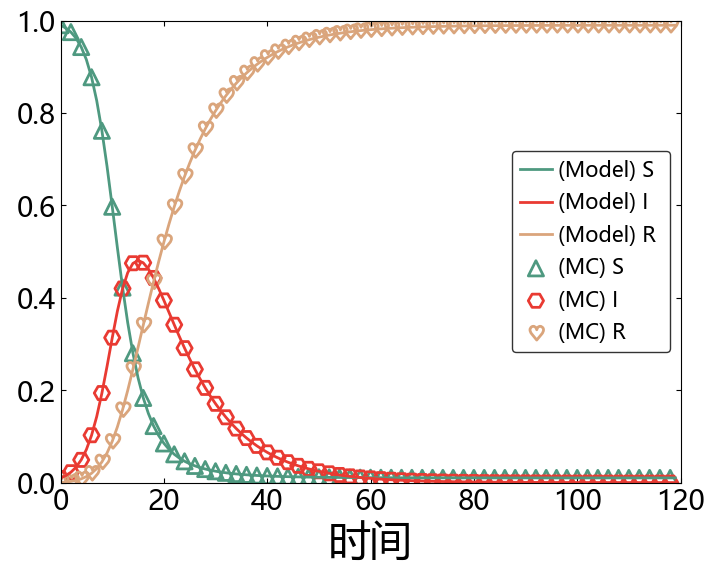

In [9]:
plt.figure(figsize=(8, 6))

states_labels = ['S', 'I', 'R']
# colors = ['#415a77', '#E54C5E', '#f77f00']
colors = ['#4E9980', '#E93A32', '#DAA57C']
markers = ['^', 'H', '$\u2665$']

for i, (label, color) in enumerate(zip(states_labels, colors)):
    sns.lineplot(data = data_MMCA_SIR[label], linewidth=2, markersize=5, color=color, label=f'(Model) {label} ')

for i, (label, color, marker) in enumerate(zip(states_labels, colors, markers)):
    sns.scatterplot(data = data_MC_SIR[label], linewidth=2, s=120, color=color,
                     label=f'(MC) {label} ', marker=marker, alpha=1, facecolor='none', edgecolor=color)

plt.xlabel('时间',fontsize='30')
plt.ylabel(' ',fontsize='1')
plt.xticks(fontsize='20')
plt.xlim(0, 120)  # 设置x轴范围
plt.yticks(fontsize='20')
plt.ylim(0, 1)  # 设置y轴范围


legend = plt.legend(
    loc='center right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    handlelength=1.5,  # 统一图标宽度
)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
plt.savefig('test1_2.pdf', bbox_inches='tight', dpi=300)
plt.show()

图3： 分解为UAU

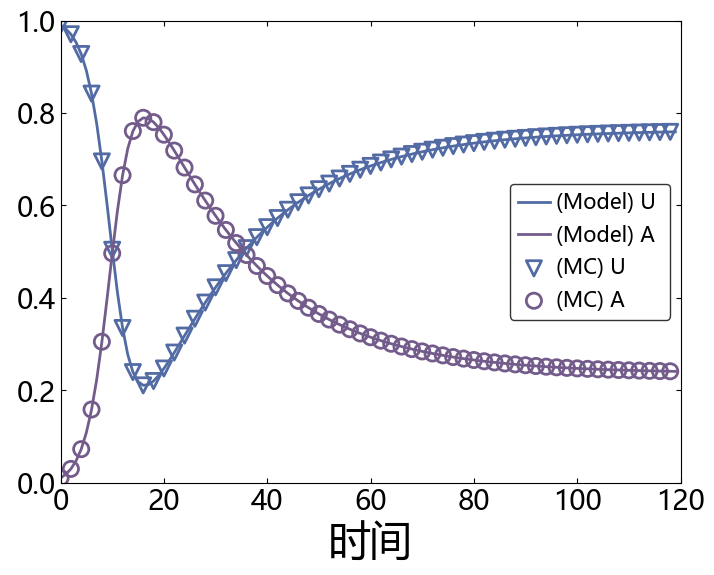

In [10]:
plt.figure(figsize=(8, 6))

states_labels = ['U', 'A']
# colors = ['#249087', '#a7c957']
colors = ['#526BA4', '#735C8B']
markers = ['v', 'o']

for i, (label, color) in enumerate(zip(states_labels, colors)):
    sns.lineplot(data = data_MMCA_UAU[label], linewidth=2, markersize=5, color=color, label=f'(Model) {label} ')

for i, (label, color, marker) in enumerate(zip(states_labels, colors, markers)):
    sns.scatterplot(data = data_MC_UAU[label], linewidth=2, s=120, color=color,
                     label=f'(MC) {label} ', marker=marker, alpha=1, facecolor='none', edgecolor=color)

plt.xlabel('时间',fontsize='30')
plt.ylabel(' ',fontsize='1')
plt.xticks(fontsize='20')
plt.xlim(0, 120)  # 设置x轴范围
plt.yticks(fontsize='20')
plt.ylim(0, 1)  # 设置y轴范围


legend = plt.legend(
    loc='center right',
    fontsize='15',
    handletextpad= 0.3,    # 图标与文本的间距
    #columnspacing=1,      # 列间距（多列时有效）
    borderpad=0.4,          # 图例内边距
    handlelength=1.5,  # 统一图标宽度
    # labelspacing=0.3,   # 图标间距
    # borderaxespad=0.5,   # 边框与图例边界的距离
)

# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)


legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

plt.savefig('test1_3.pdf', bbox_inches='tight', dpi=300)
plt.show()